# Modelo Cuantitativo de Riesgo: Value at Risk (VaR) por Montecarlo

Este *notebook* implementa un motor de evaluación de riesgo financiero para medir la exposición a pérdidas de un portafolio. Mediante la **Simulación de Montecarlo**, se modela la incertidumbre de los mercados financieros generando escenarios basados en la volatilidad y los retornos históricos. El objetivo final es cuantificar el **VaR**, una de las métricas de control de riesgo más estandarizadas en la industria bancaria y de *hedge funds*.

## 1. Configuración del Entorno y Adquisición de Datos

Inicializamos las librerías matemáticas y de manipulación de datos. Posteriormente, definimos los activos de nuestro portafolio, el capital inicial y extraemos la serie histórica de precios para tener una base solida sobre la cual calibrar nuestra simulación.

In [ ]:
import numpy as np
import pandas as pd
import datetime as dt 
import yfinance as yf
import matplotlib.pyplot as plt 
from scipy.stats import norm 

years = 15

EndDate = dt.datetime.now()
StartDate = EndDate - dt.timedelta(days=years*365)

tickers = ['SPY', 'BND' , 'GLD', 'QQQ','VTI']

close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=StartDate, end=EndDate)
    close_df[ticker] = data['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 2. Calibración Estadística de los Parámetros del Mercado

Para que la simulación de Montecarlo tenga validez financiera, los escenarios aleatorios deben estar basados en la realidad. Calculamos los rendimientos históricos de los activos para extraer dos parámetros fundamentales:
* **El Rendimiento Esperado ($\mu$):** La tendencia central de crecimiento del activo.
* **La Volatilidad ($\sigma$):** La desviación estándar de los retornos, que actuará como la medida de incertidumbre en la simulación.

In [37]:
log_returns = np.log(close_df / close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

def expected_return(weights, log_returns):
    return np.sum(log_returns.mean() * weights)

def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)


#Calculamos la matriz de covarianza de los rendimientos logarítmicos
cov_matrix = log_returns.cov()
print(cov_matrix)

                 SPY       BND       GLD       QQQ       VTI
Date                                                        
2011-07-19  0.016102  0.002688 -0.012274  0.022511  0.016711
2011-07-20 -0.000603 -0.001587  0.008755 -0.004257 -0.000582
2011-07-21  0.013776 -0.002203 -0.007656  0.006633  0.012144
2011-07-22  0.000669  0.002692  0.008297  0.010288  0.001723
2011-07-25 -0.005588 -0.003304  0.007784 -0.002015 -0.006477
...              ...       ...       ...       ...       ...
2026-07-08 -0.003094 -0.002061 -0.008086  0.002829 -0.003686
2026-07-09  0.008430  0.001787  0.009912  0.016505  0.008652
2026-07-10  0.004301 -0.000824 -0.003099  0.003078  0.003333
2026-07-13 -0.007686 -0.003717 -0.026556 -0.019162 -0.007839
2026-07-14  0.003544  0.002755  0.013581  0.011136  0.003725

[3768 rows x 5 columns]
          SPY       BND       GLD       QQQ       VTI
SPY  0.000118  0.000002  0.000007  0.000133  0.000120
BND  0.000002  0.000010  0.000010  0.000003  0.000002
GLD  0.000007  0.000

## 3. Motor de Simulación de Montecarlo

En esta sección iteramos miles de veces para generar trayectorias posibles de precios o rendimientos. La base de esta proyección asume que el cambio en el valor del activo contiene un componente predecible (la media) y un componente aleatorio.

La simulación extrae números aleatorios $Z$ de una distribución normal estándar ($Z \sim N(0,1)$), los escala por la volatilidad del activo y los proyecta hacia el futuro para crear un miles de escenarios finales posibles para el portafolio.

In [ ]:
portafolio_value = 1000000
weights = np.array ([1/len(tickers)] * len(tickers))
portafolio_expected_return = expected_return(weights, log_returns)
portafolio_std_dev = standard_deviation (weights, cov_matrix)

def random_z_score():
    return np.random.normal(0,1)

## 4. Cuantificación del Value at Risk (VaR)

Con miles de resultados finales simulados, determinamos la ganancia o pérdida neta (PnL) de cada escenario. Para hallar el **VaR**, ordenamos estadísticamente esta distribución de PnL de peor a mejor. 

El Value at Risk será el valor que corta la "cola" izquierda de la distribución en nuestro nivel de significancia. Por ejemplo, en un VaR al 95%, aislamos el percentil 5; esto nos indica que, bajo condiciones normales, hay un 95% de probabilidad de que nuestras pérdidas **no superen** esta barrera proyectada.

In [36]:
days = 20

def scenario_gain_loss(portafolio_value, portafolio_std_dev, z_score, days):
    return portafolio_value * portafolio_expected_return * days + portafolio_value * portafolio_std_dev * z_score * np.sqrt(days)


simulations = 10000
scenarioReturn =[]


for i in range(simulations):
    z_score = random_z_score()
    scenarioReturn.append(scenario_gain_loss(portafolio_value, portafolio_std_dev, z_score, days))



confidence_interval = 0.95
VaR = -np.percentile(scenarioReturn, (1-confidence_interval)*100)
print(VaR)

47021.52179992774


## 5. Análisis Visual de la Distribución de Riesgo (PnL)

La visualización de la distribución simulada es crucial para los analistas de riesgo. El siguiente histograma ilustra la frecuencia de los distintos escenarios de pérdidas y ganancias. La línea roja muestra gráficamente el umbral del **Value at Risk**, evidenciando el *Tail Risk* (riesgo de cola) al que está expuesto el portafolio.

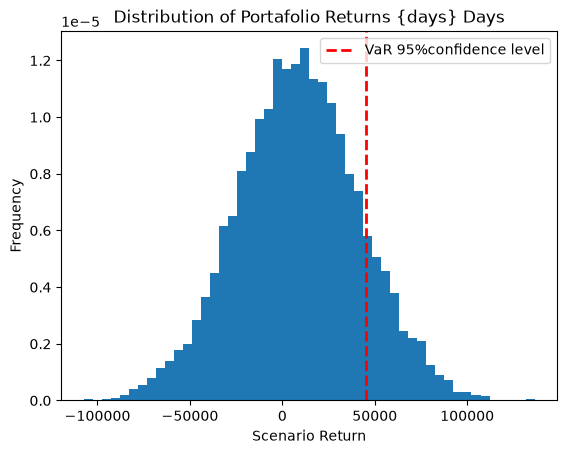

In [27]:
plt.hist(scenarioReturn, bins=50, density=True)
plt.xlabel('Scenario Return')
plt.ylabel('Frequency')
plt.title('Distribution of Portafolio Returns {days} Days')
plt.axvline(VaR, color = 'r', linestyle='dashed', linewidth=2, label=f'VaR {confidence_interval:.0%}confidence level')
plt.legend()
plt.show()

## 6. Conclusiones y Diagnóstico de Riesgo (Risk Assessment)

Bajo los parámetros establecidos para este ejercicio de medición cuantitativa, se ejecutó un motor de Montecarlo con **10,000 simulaciones** proyectadas a un horizonte de liquidez de **20 días** operacionales. 

El portafolio analizado partió de un capital inicial de **$1,000,000 USD**, estructurado bajo pesos equitativos. Se asignó exactamente un **20%** de ponderación a cada uno de los cinco activos que componen el portafolio de inversión (`SPY`, `BND`, `GLD`, `QQQ`, `VTI`). Esta estructura  balancea el campo tecnologico y corporativo, renta fija general y materias primas (oro).

### Interpretación Financiera del Value at Risk (VaR)
El modelo estocástico determinó un VaR de **$47,021 USD** a un nivel de confianza del **95%**. En términos de gestión de riesgos institucionales, este resultado se traduce en las siguientes premisas operativas:

* Existe un **95% de probabilidad** de que las pérdidas acumuladas del portafolio **no superen** los $47,021 USD al finalizar el periodo de 20 días, asumiendo una dinámica de mercado en condiciones normales.
* En términos relativos, la máxima pérdida esperada representa una caída de tan solo el **4.7%** respecto al capital total invertido.
* Existe una probabilidad residual del **5%** (riesgo de cola o *Tail Risk*) de que las minusvalías excedan dicha barrera, escenario para el cual las instituciones financieras deben mantener capital regulatorio de reserva.

### Veredicto Cuantitativo
La magnitud del riesgo proyectado es directamente consistente con los beneficios de la diversificación (*Diversification Benefit*). La inclusión de activos descorrelacionados o defensivos como el oro (`GLD`) y los bonos (`BND`) mitiga eficientemente la volatilidad de los activos sobre renta variable (`QQQ`, `SPY`, `VTI`). Una exposición al riesgo de mercado por debajo del 5% en un horizonte mensual se considera un nivel de riesgo **moderado-conservador**, altamente aceptable para la tolerancia estándar de fondos *Long-Only* y mandatos de preservación de capital.